In [58]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.special import erfc
from sklearn.metrics import confusion_matrix
import pandas as pd
import sounddevice as sd
from scipy.io.wavfile import read
from collections import Counter
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.metrics import ConfusionMatrixDisplay


In [59]:
# ================== BESTEMME FIL ====================



GenreClassData = "Music files/GenreClassData_30s.txt"
#GenreClassData = "Music files/GenreClassData_10s.txt"
#GenreClassData = "Music files/GenreClassData_5s.txt"

# ================== BESTEMME FIL ====================

# OPPGAVE 1

### Kode som leser txt filen med informasjon

In [60]:
import pandas as pd

def load_genre_data_by_range(start_row, end_row, GenreClassData):
    # Les kun de nødvendige kolonnene (brukercols for å spesifisere kolonneindekser)
    cols_to_load = [2-1, 7-1, 11-1, 41-1, 42-1]  
    col_names = ["name",'spectral centroid mean', 'spectral rolloff mean', 'tempo', 'mfcc 1 mean']  
    
    data = pd.read_csv(GenreClassData, sep=r'\s+', header=None, usecols=cols_to_load)
    data.columns = col_names 
    
    row_indices = range(start_row+1, end_row + 2)
    selected_rows = data.iloc[row_indices]
    
    return selected_rows



def load_genre_data_by_type(GenreClassData):
    cols_to_load = [2-1, 7-1, 11-1, 41-1, 42-1, 68-1]  
    col_names = ["name", 'spectral centroid mean', 'spectral rolloff mean', 'tempo', 'mfcc 1 mean', "type"] 
    
    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {7-1: float, 11-1: float, 41-1: float, 42-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    # Sett kolonnenavn
    data.columns = col_names 
    
    # Filtrer trenings- og testdata
    train_data = data[data['type'] == 'Train']
    test_data = data[data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    
    return train_data, test_data


def load_genre_data_by_name(data_set, name):
    navngittdata = []  # Bruker en vanlig liste

    for rad in data_set:
        if name in rad[0]:
            navngittdata.append(list(rad[1:]))

    return navngittdata



popdata_index = [0,99]
#pop_Data = load_genre_data_by_range(popdata_index[0], popdata_index[1], GenreClassData)
#print(pop_Data)

train_data, test_data = load_genre_data_by_type(GenreClassData)
print(train_data)

pop_Data = load_genre_data_by_name(train_data.values,"pop")
#print(pop_Data)
pop_Data = np.array(pop_Data)
#print(pop_Data.shape)

               name  spectral centroid mean  spectral rolloff mean  \
0     pop_00072.wav             2569.255823            5351.909304   
1     pop_00066.wav             2844.070408            6839.566975   
2     pop_00099.wav             2765.648135            6873.341771   
3     pop_00098.wav             3634.106564            7534.996104   
4     pop_00073.wav             3671.260489            7879.044023   
..              ...                     ...                    ...   
787  jazz_00059.wav             1397.404475            2932.498934   
788  jazz_00067.wav             1354.091908            2830.541217   
789  jazz_00073.wav             2968.602505            6416.761199   
790  jazz_00099.wav             1492.564531            3376.796248   
791  jazz_00066.wav             1579.012766            2967.207058   

          tempo  mfcc 1 mean  
0    117.453835     9.675074  
1    107.666016   -63.635056  
2    161.499023  -119.346458  
3    117.453835   -26.936581  
4   

## k_NN funksjon

#### Euclidisk avstand

In [61]:

def euclidean_distance_4d(vec1, vec2):
    """
    Beregner euklidisk avstand mellom to 4-dimensjonale vektorer.
    
    Parametere:
    vec1 : array-like
        Første 4-dimensjonale vektor.
    vec2 : array-like
        Andre 4-dimensjonale vektor.
    
    Returnerer:
    float
        Den euklidiske avstanden mellom de to vektorene.
    """
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    distance = np.sqrt(np.sum((vec1 - vec2) ** 2))
    return distance


##### Normalisert data

In [62]:
train_data, test_data = load_genre_data_by_type(GenreClassData)

def load_scaled_data_with_names(train_data, test_data):
    scaler = StandardScaler()
    
    train_features = train_data.iloc[:, 1:].values
    test_features = test_data.iloc[:, 1:].values
    
    train_names = train_data.iloc[:, 0].values
    test_names = test_data.iloc[:, 0].values
    
    train_scaled = scaler.fit_transform(train_features)
    test_scaled = scaler.transform(test_features)
    
    # Kombiner navnene med de skalerte funksjonene i en DataFrame
    train_scaled_with_name = pd.DataFrame(
        data=train_scaled, 
        columns=train_data.columns[1:]
    )
    train_scaled_with_name.insert(0, "Name", train_names)
    
    test_scaled_with_name = pd.DataFrame(
        data=test_scaled, 
        columns=test_data.columns[1:]
    )
    test_scaled_with_name.insert(0, "Name", test_names)
    
    return train_scaled_with_name, test_scaled_with_name


# Bruk funksjonen
train_scaled_with_name, test_scaled_with_name = load_scaled_data_with_names(train_data, test_data)

print(f"Treningsdata med navn:\n{train_scaled_with_name}\n")
print(f"Testdata med navn:\n{test_scaled_with_name}\n")


Treningsdata med navn:
               Name  spectral centroid mean  spectral rolloff mean     tempo  \
0     pop_00072.wav                0.536861               0.514616 -0.186702   
1     pop_00066.wav                0.923806               1.462477 -0.651477   
2     pop_00099.wav                0.813386               1.483997  1.904788   
3     pop_00098.wav                2.036194               1.905570 -0.186702   
4     pop_00073.wav                2.088507               2.124780  0.371029   
..              ...                     ...                    ...       ...   
787  jazz_00059.wav               -1.113130              -1.026912 -0.651477   
788  jazz_00067.wav               -1.174115              -1.091875 -0.855978   
789  jazz_00073.wav                1.099150               1.193086 -0.429193   
790  jazz_00099.wav               -0.979143              -0.743828  0.693925   
791  jazz_00066.wav               -0.857422              -1.004798  0.371029   

     mfcc 1 mean

### k-NN

In [63]:
def k_nn(train_data, test_instance, k):
    avstand = []
    for data in train_data:
        dist = euclidean_distance_4d(data[1:], test_instance)
        
        avstand.append((data, dist))
    avstand.sort(key=lambda x: x[1])
    k_nearest = avstand[:k]
    
    classes = [neighbor[0][0].split('_')[0] for neighbor in k_nearest]
    class_counts = Counter(classes)
    #MÅ LEGGE TIL NOE SOM BEHANDLER OM DET ER LIK MANGE AV TO KLASSER, DA VIL DEN VELGE DEN SOM ER NÆRMEST
    
    # Finn klassen(e) med høyest antall
    max_count = max(class_counts.values())
    tied_classes = [cls for cls, count in class_counts.items() if count == max_count]
    
    if len(tied_classes) > 1:  # Hvis det er en tie
        for neighbor in k_nearest:
            neighbor_class = neighbor[0][0].split('_')[0]
            if neighbor_class in tied_classes:
                most_common_class = neighbor_class
                break
    else:
        most_common_class = tied_classes[0]
    
    #print(f"Klassefordeling: {class_counts}")
    #print(f"Mest vanlig klasse: {most_common_class}, Antall: {count}")
    
    data_points = [neighbor[0] for neighbor in k_nearest]
    distances = [neighbor[1] for neighbor in k_nearest]
    data_points_array = np.array(data_points)
    distances_array = np.array(distances)

    return most_common_class, data_points_array, distances_array


#Eksempelbruk
test_data_tilfellet = test_data.values[4][1:]
print(f"Testdata tilfelle: {test_data_tilfellet}")
k_nearest = k_nn(train_data.values, test_data_tilfellet, 5)

print(f"Predikert klasse: {k_nearest[0]}")
print(f"Nærmeste naboer:\n{k_nearest[1]}")
print(f"Avstander til nærmeste naboer:\n{k_nearest[2]}")



Testdata tilfelle: [3419.344748584225 7789.061233945676 83.35433467741936 -93.63922119140624]
Predikert klasse: pop
Nærmeste naboer:
[['rock_00057.wav' 3488.995725234682 7660.57034424584 123.046875
  -58.60115051269531]
 ['pop_00054.wav' 3498.3579748468533 7664.611986473249 129.19921875
  -46.7030143737793]
 ['pop_00000.wav' 3422.09468149683 7953.293574188516 135.99917763157896
  -94.53428649902344]
 ['pop_00097.wav' 3510.042356887174 7587.437453137094 99.38401442307692
  -125.53952026367188]
 ['disco_00035.wav' 3623.816329767186 7702.895088313903 123.046875
  -51.813499450683594]]
Avstander til nærmeste naboer:
[155.44880649 161.35509297 172.48798319 223.94817448 229.25557991]


## Evaluering

Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen
Klasser: ['pop', 'rock', 'hiphop', 'jazz', 'classical', 'metal', 'country', 'disco', 'blues', 'reggae']



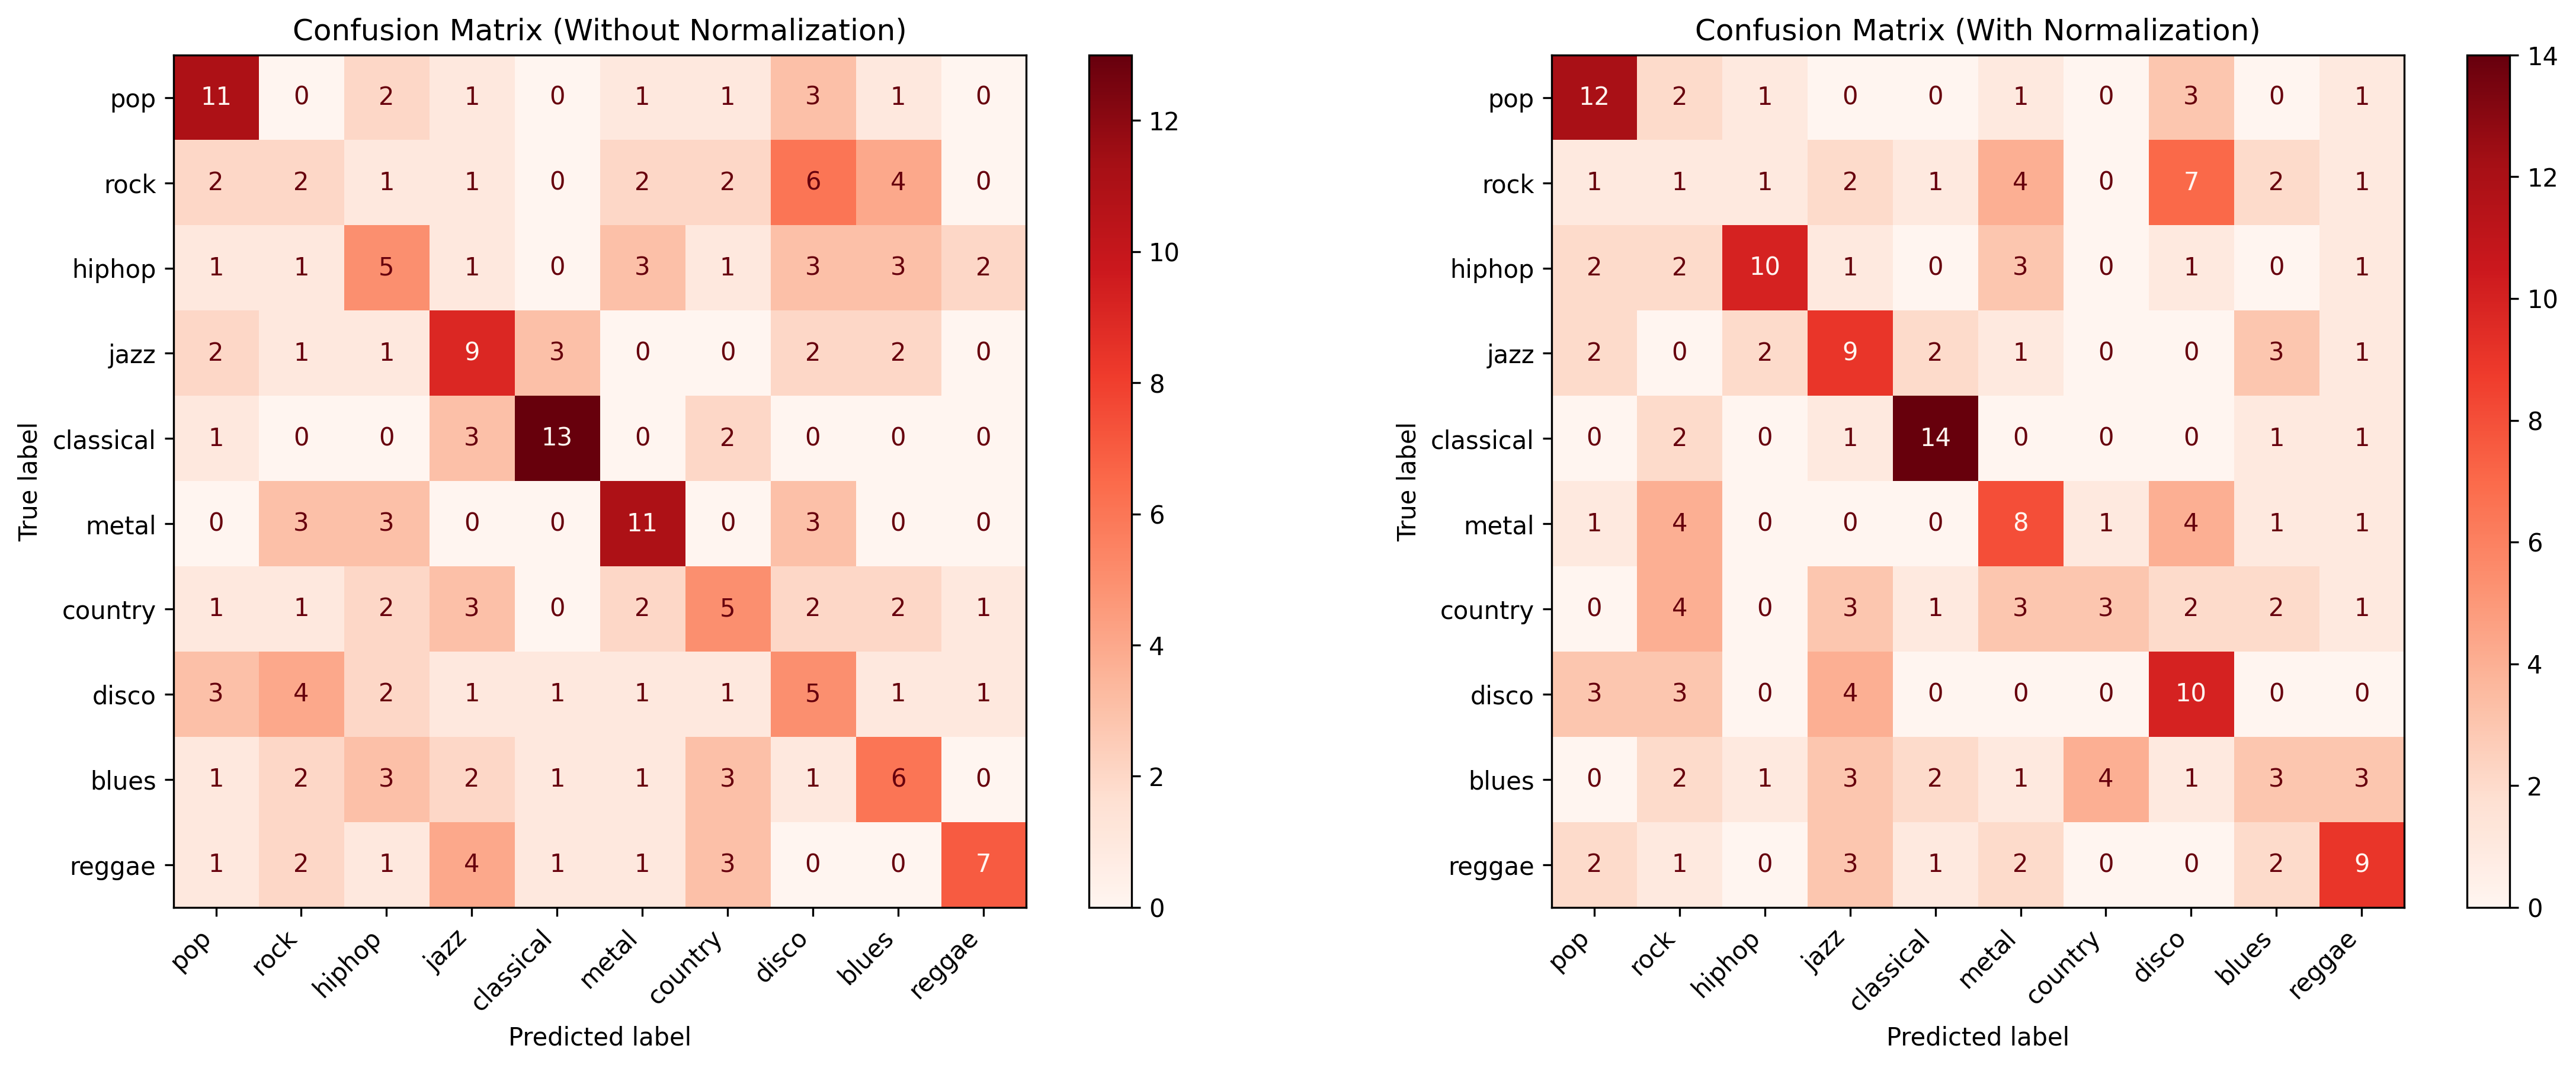


Accuracy: 37.37%
Accuracy med normalisert data: 39.90%


In [64]:
train_data, test_data = load_genre_data_by_type(GenreClassData)
test_pop_data = np.array(load_genre_data_by_name(test_data.values,"pop"))
classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]


def evaluering(train_data, test_data, k):
    y_true = []
    y_pred = []
    for test_instance in test_data.values:
        true_label = test_instance[0].split('_')[0]
        predicted_label, _, _ = k_nn(train_data.values, test_instance[1:], k)
        y_pred.append(predicted_label)
        y_true.append(true_label)
    cm = confusion_matrix(y_true, y_pred,labels=classes)
    return cm


def accuracy_percent(cm):
    import numpy as np
    return 100 * np.trace(cm) / np.sum(cm)


# Eksempelbruk
k = 5
conf_matrix = evaluering(train_data, test_data, k) 
print(f"Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen")
print(f"Klasser: {classes}\n")

#Med normalisert data
conf_matrix_normalized = evaluering(train_scaled_with_name, test_scaled_with_name, k)

# Plot begge confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Plot 1: Uten normalisering
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp1.plot(ax=ax[0], colorbar=True, cmap='Reds')
ax[0].set_title('Confusion Matrix (Without Normalization)')
ax[0].set_xticklabels(classes, rotation=45, ha='right')

# Plot 2: Med normalisering
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_normalized, display_labels=classes)
disp2.plot(ax=ax[1], colorbar=True, cmap='Reds')
ax[1].set_title('Confusion Matrix (With Normalization)')
ax[1].set_xticklabels(classes, rotation=45, ha='right')

plt.tight_layout()

#plt.savefig('Figures/cm_oppgave_1.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil

plt.show()

print(f"\nAccuracy: {accuracy_percent(conf_matrix):.2f}%")
print(f"Accuracy med normalisert data: {accuracy_percent(conf_matrix_normalized):.2f}%")

## Evaluering av k-NN klassifikator



### Confusion Matrix
Confusion matrixen viser forholdet mellom sanne klasser (rader) og predikerte klasser (kolonner). Diagonalelementene representerer riktige klassifiseringer, mens elementer utenfor diagonalen representerer feilklassifiseringer.

---

### Accuracy
For 30 sekunder:

Totalt antall testeksempler: 198  

- Uten normalisering: 74 riktige  
$
\text{accuracy} = \frac{74}{198} \approx 0.374
$

- Med normalisering: 79 riktige  
$
\text{accuracy} = \frac{79}{198} \approx 0.399
$

Normalisering gir dermed en økning i nøyaktighet fra **37.4% til 39.9%**.

---


### Tolkning

Normalisering reduserer effekten av at enkelte features dominerer avstandsberegningen. Dette gir en mer balansert bruk av alle features i k-NN.

Resultatet er:
- bedre klassifikasjon for noen klasser (spesielt **hiphop** og **disco**)  
- noe dårligere for andre (f.eks. **metal** og **country**)  

Totalt sett gir dette en forbedring i modellens ytelse.

---

### Konklusjon

k-NN-modellen med \(k=5\) gir relativt lav nøyaktighet både med og uten normalisering, men normalisering forbedrer resultatet fra ca. 37% til ca. 40%.

Dette viser at:
- k-NN er sensitiv for skalaen til input-features  
- normalisering er viktig for å oppnå bedre ytelse  

Selv med normalisering er ytelsen begrenset, noe som tyder på at de valgte feature-ene ikke er tilstrekkelige til å skille alle sjangrene tydelig. Dette fører fortsatt til systematiske feilklassifiseringer mellom overlappende klasser.

# OPPGAVE 2

### DATA EXTRACTION

In [65]:

train_data, test_data = load_genre_data_by_type(GenreClassData)
print(train_data)
pop_data_train = load_genre_data_by_name(train_data.values,"pop")
pop_data_test = load_genre_data_by_name(test_data.values,"pop")
disco_data_train = load_genre_data_by_name(train_data.values,"disco")
disco_data_test = load_genre_data_by_name(test_data.values,"disco")
metal_data_train = load_genre_data_by_name(train_data.values,"metal")
metal_data_test = load_genre_data_by_name(test_data.values,"metal")
classical_data_train = load_genre_data_by_name(train_data.values,"classical")
classical_data_test = load_genre_data_by_name(test_data.values,"classical")


pop_data_sorted = np.transpose(np.array(pop_data_train + pop_data_test))
disco_data_sorted = np.transpose(np.array(disco_data_train + disco_data_test))
metal_data_sorted = np.transpose(np.array(metal_data_train + metal_data_test))
classical_data_sorted = np.transpose(np.array(classical_data_train + classical_data_test))

print(pop_data_sorted.shape)

#print(f"Pop data train: {(pop_data)}")
#print(f"Disco data train: {(disco_data)}")


               name  spectral centroid mean  spectral rolloff mean  \
0     pop_00072.wav             2569.255823            5351.909304   
1     pop_00066.wav             2844.070408            6839.566975   
2     pop_00099.wav             2765.648135            6873.341771   
3     pop_00098.wav             3634.106564            7534.996104   
4     pop_00073.wav             3671.260489            7879.044023   
..              ...                     ...                    ...   
787  jazz_00059.wav             1397.404475            2932.498934   
788  jazz_00067.wav             1354.091908            2830.541217   
789  jazz_00073.wav             2968.602505            6416.761199   
790  jazz_00099.wav             1492.564531            3376.796248   
791  jazz_00066.wav             1579.012766            2967.207058   

          tempo  mfcc 1 mean  
0    117.453835     9.675074  
1    107.666016   -63.635056  
2    161.499023  -119.346458  
3    117.453835   -26.936581  
4   

### Histogram

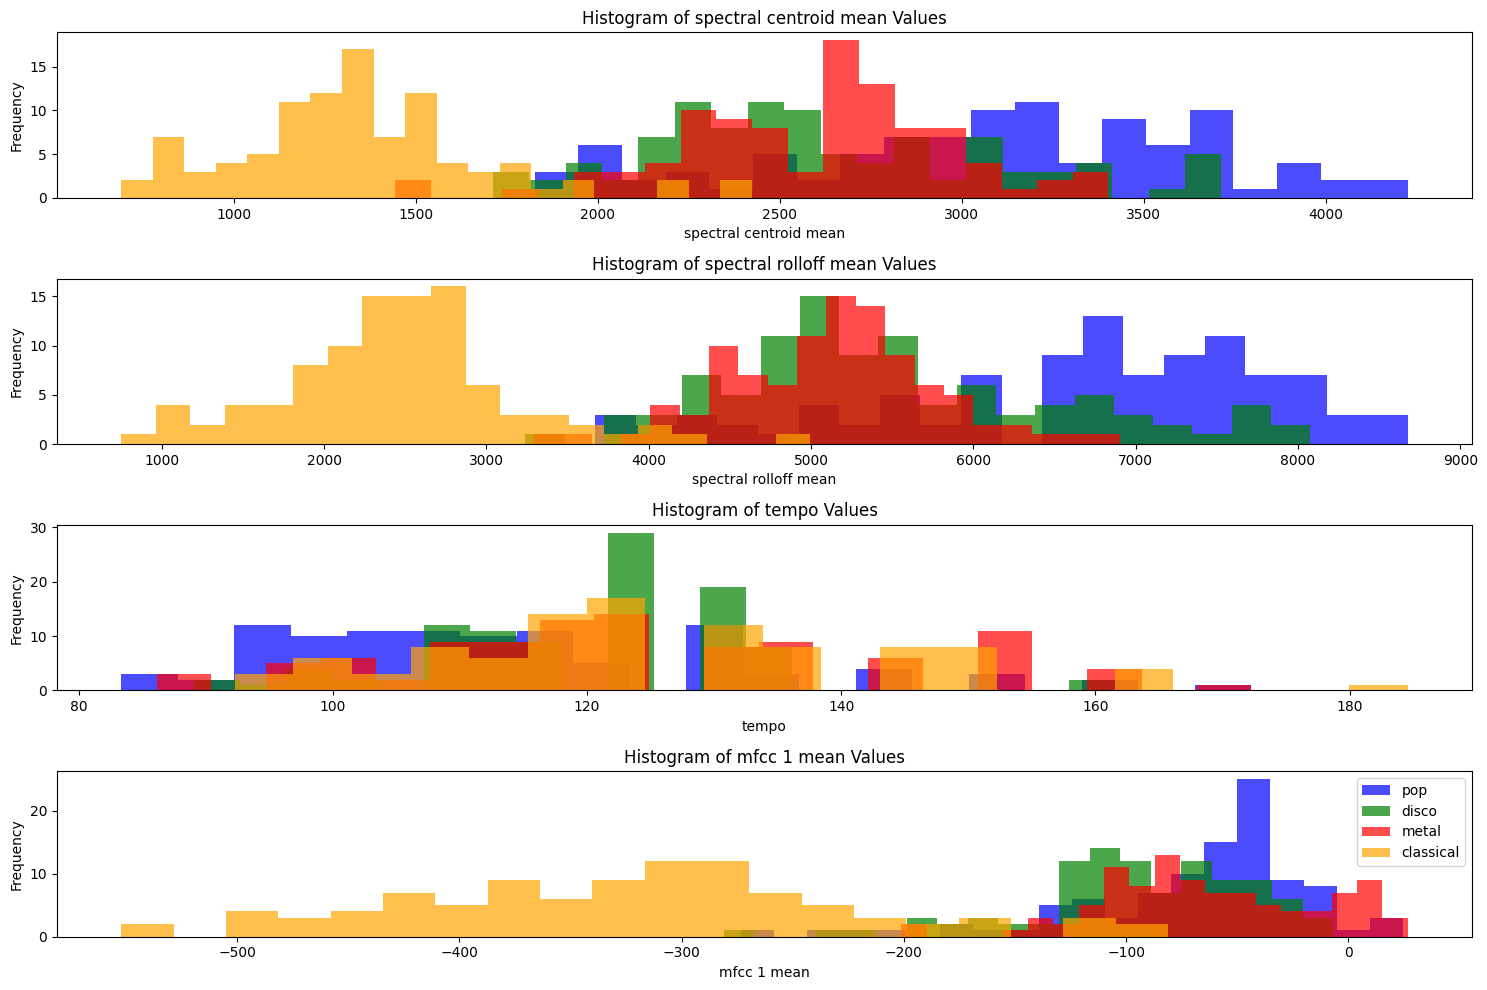

In [66]:
# Data fra den markerte koden
classes = ['pop', 'disco', 'metal', 'classical']
data = [pop_data_sorted, disco_data_sorted, metal_data_sorted, classical_data_sorted]
colors = ['blue', 'green', 'red', 'orange']



# histogram
plt.figure(figsize=(15, 10))
plt.subplot(4, 1, 1)
for i,cls in enumerate(classes):
    plt.hist(data[i][0], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of spectral centroid mean Values')
plt.xlabel('spectral centroid mean')
plt.ylabel('Frequency')

plt.subplot(4, 1, 2)
for i,cls in enumerate(classes):
    plt.hist(data[i][1], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of spectral rolloff mean Values')
plt.xlabel('spectral rolloff mean')
plt.ylabel('Frequency')

plt.subplot(4, 1, 3)
for i,cls in enumerate(classes):
    plt.hist(data[i][2], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of tempo Values')
plt.xlabel('tempo')
plt.ylabel('Frequency')

plt.subplot(4, 1, 4)
for i,cls in enumerate(classes):
    plt.hist(data[i][3], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of mfcc 1 mean Values')
plt.xlabel('mfcc 1 mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.legend()

#plt.savefig('Figures/histogram_oppgave_2.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil

plt.show()




### BOX

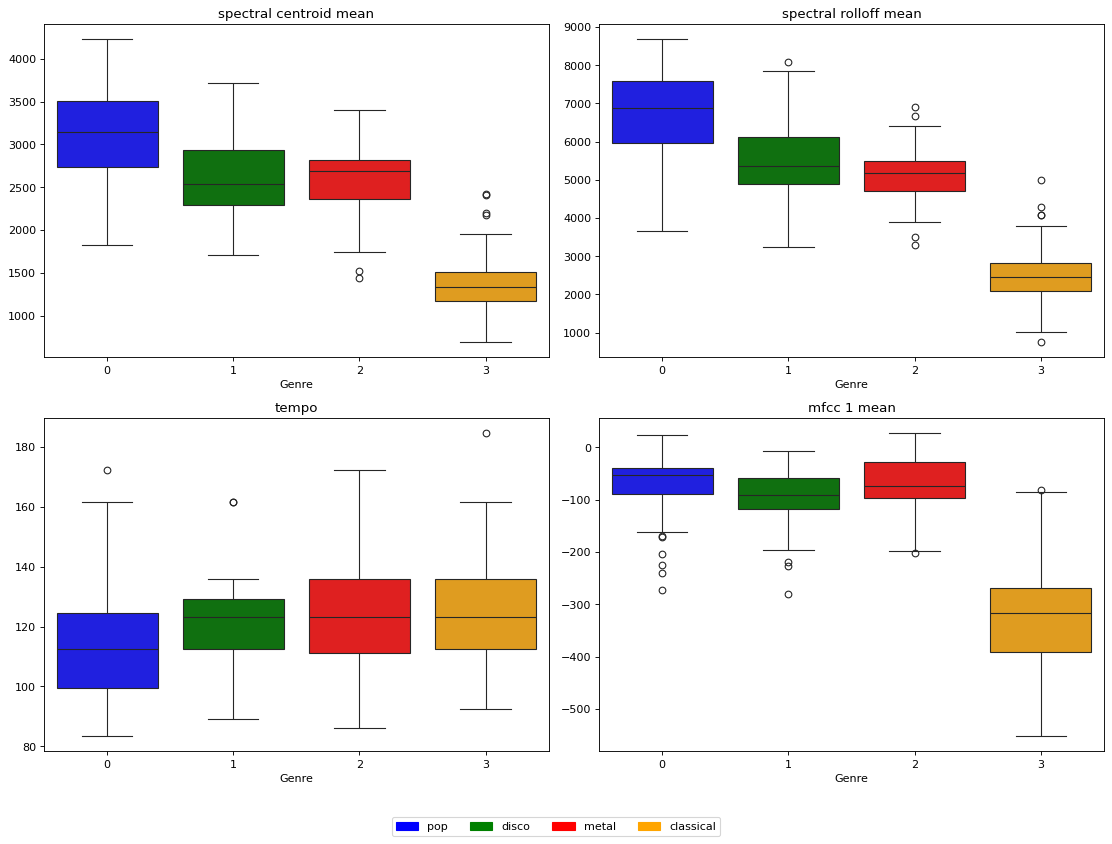

In [67]:
Data_0 = [
    pop_data_sorted[0],
    disco_data_sorted[0],
    metal_data_sorted[0],
    classical_data_sorted[0]
]

Data_1 = [
    pop_data_sorted[1],
    disco_data_sorted[1],
    metal_data_sorted[1],
    classical_data_sorted[1]
]

Data_2 = [
    pop_data_sorted[2],
    disco_data_sorted[2],
    metal_data_sorted[2],
    classical_data_sorted[2]
]

Data_3 = [
    pop_data_sorted[3],
    disco_data_sorted[3],
    metal_data_sorted[3],
    classical_data_sorted[3]
]

classes = ['pop', 'disco', 'metal', 'classical']
colors = ['blue', 'green', 'red', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=80)

sns.boxplot(data=Data_0, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title('spectral centroid mean')
axes[0, 0].set_xlabel('Genre')

sns.boxplot(data=Data_1, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title('spectral rolloff mean')
axes[0, 1].set_xlabel('Genre')

sns.boxplot(data=Data_2, palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('tempo')
axes[1, 0].set_xlabel('Genre')

sns.boxplot(data=Data_3, palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('mfcc 1 mean')
axes[1, 1].set_xlabel('Genre')

# Lag legend manuelt
handles = [
    mpatches.Patch(color=colors[i], label=classes[i])
    for i in range(len(classes))
]

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4)
plt.tight_layout()
plt.show()

# OPPGAVE 3

## Data extraction

In [68]:
def load_spesific_data(GenreClassData,name,colon_from_pdf,colon_name):
    cols_to_load = [2-1, colon_from_pdf-1, 68-1]  
    col_names = ["name", colon_name, "type"] 
    
    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {colon_from_pdf-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    ny_data = []
    for rad in data.values:
        if name in rad[0]:
            ny_data.append(list(rad[1:]))

    # Konverter listen til DataFrame med riktige kolonnenavn
    
    ny_data = pd.DataFrame(ny_data, columns=[colon_name, "type"])
    
    # Filtrer trenings- og testdata
    train_data = ny_data[ny_data['type'] == 'Train']
    test_data = ny_data[ny_data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    data_sorted = np.concatenate((train_data.values, test_data.values), axis=0).T.squeeze()
    return data_sorted




classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]

Data_mfcc_2_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 43, "mfcc_2_mean")
    Data_mfcc_2_mean.append(data_for_genre)


Data_mfcc_3_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 44, "mfcc_3_mean")
    Data_mfcc_3_mean.append(data_for_genre)


Data_spectral_bandwidth_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 9, "spectral_bandwidth_mean")
    Data_spectral_bandwidth_mean.append(data_for_genre)


Data_zero_cross_rate_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 3, "zero_cross_rate_mean")
    Data_zero_cross_rate_mean.append(data_for_genre)
                            

Data_rmse_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 5, "rmse_mean")
    Data_rmse_mean.append(data_for_genre)


Data_spectral_flatness_mean = []
for genre in classes:
    data_for_genre = load_spesific_data(GenreClassData, genre, 15, "spectral_flatness_mean")
    Data_spectral_flatness_mean.append(data_for_genre)



## PLOTTING

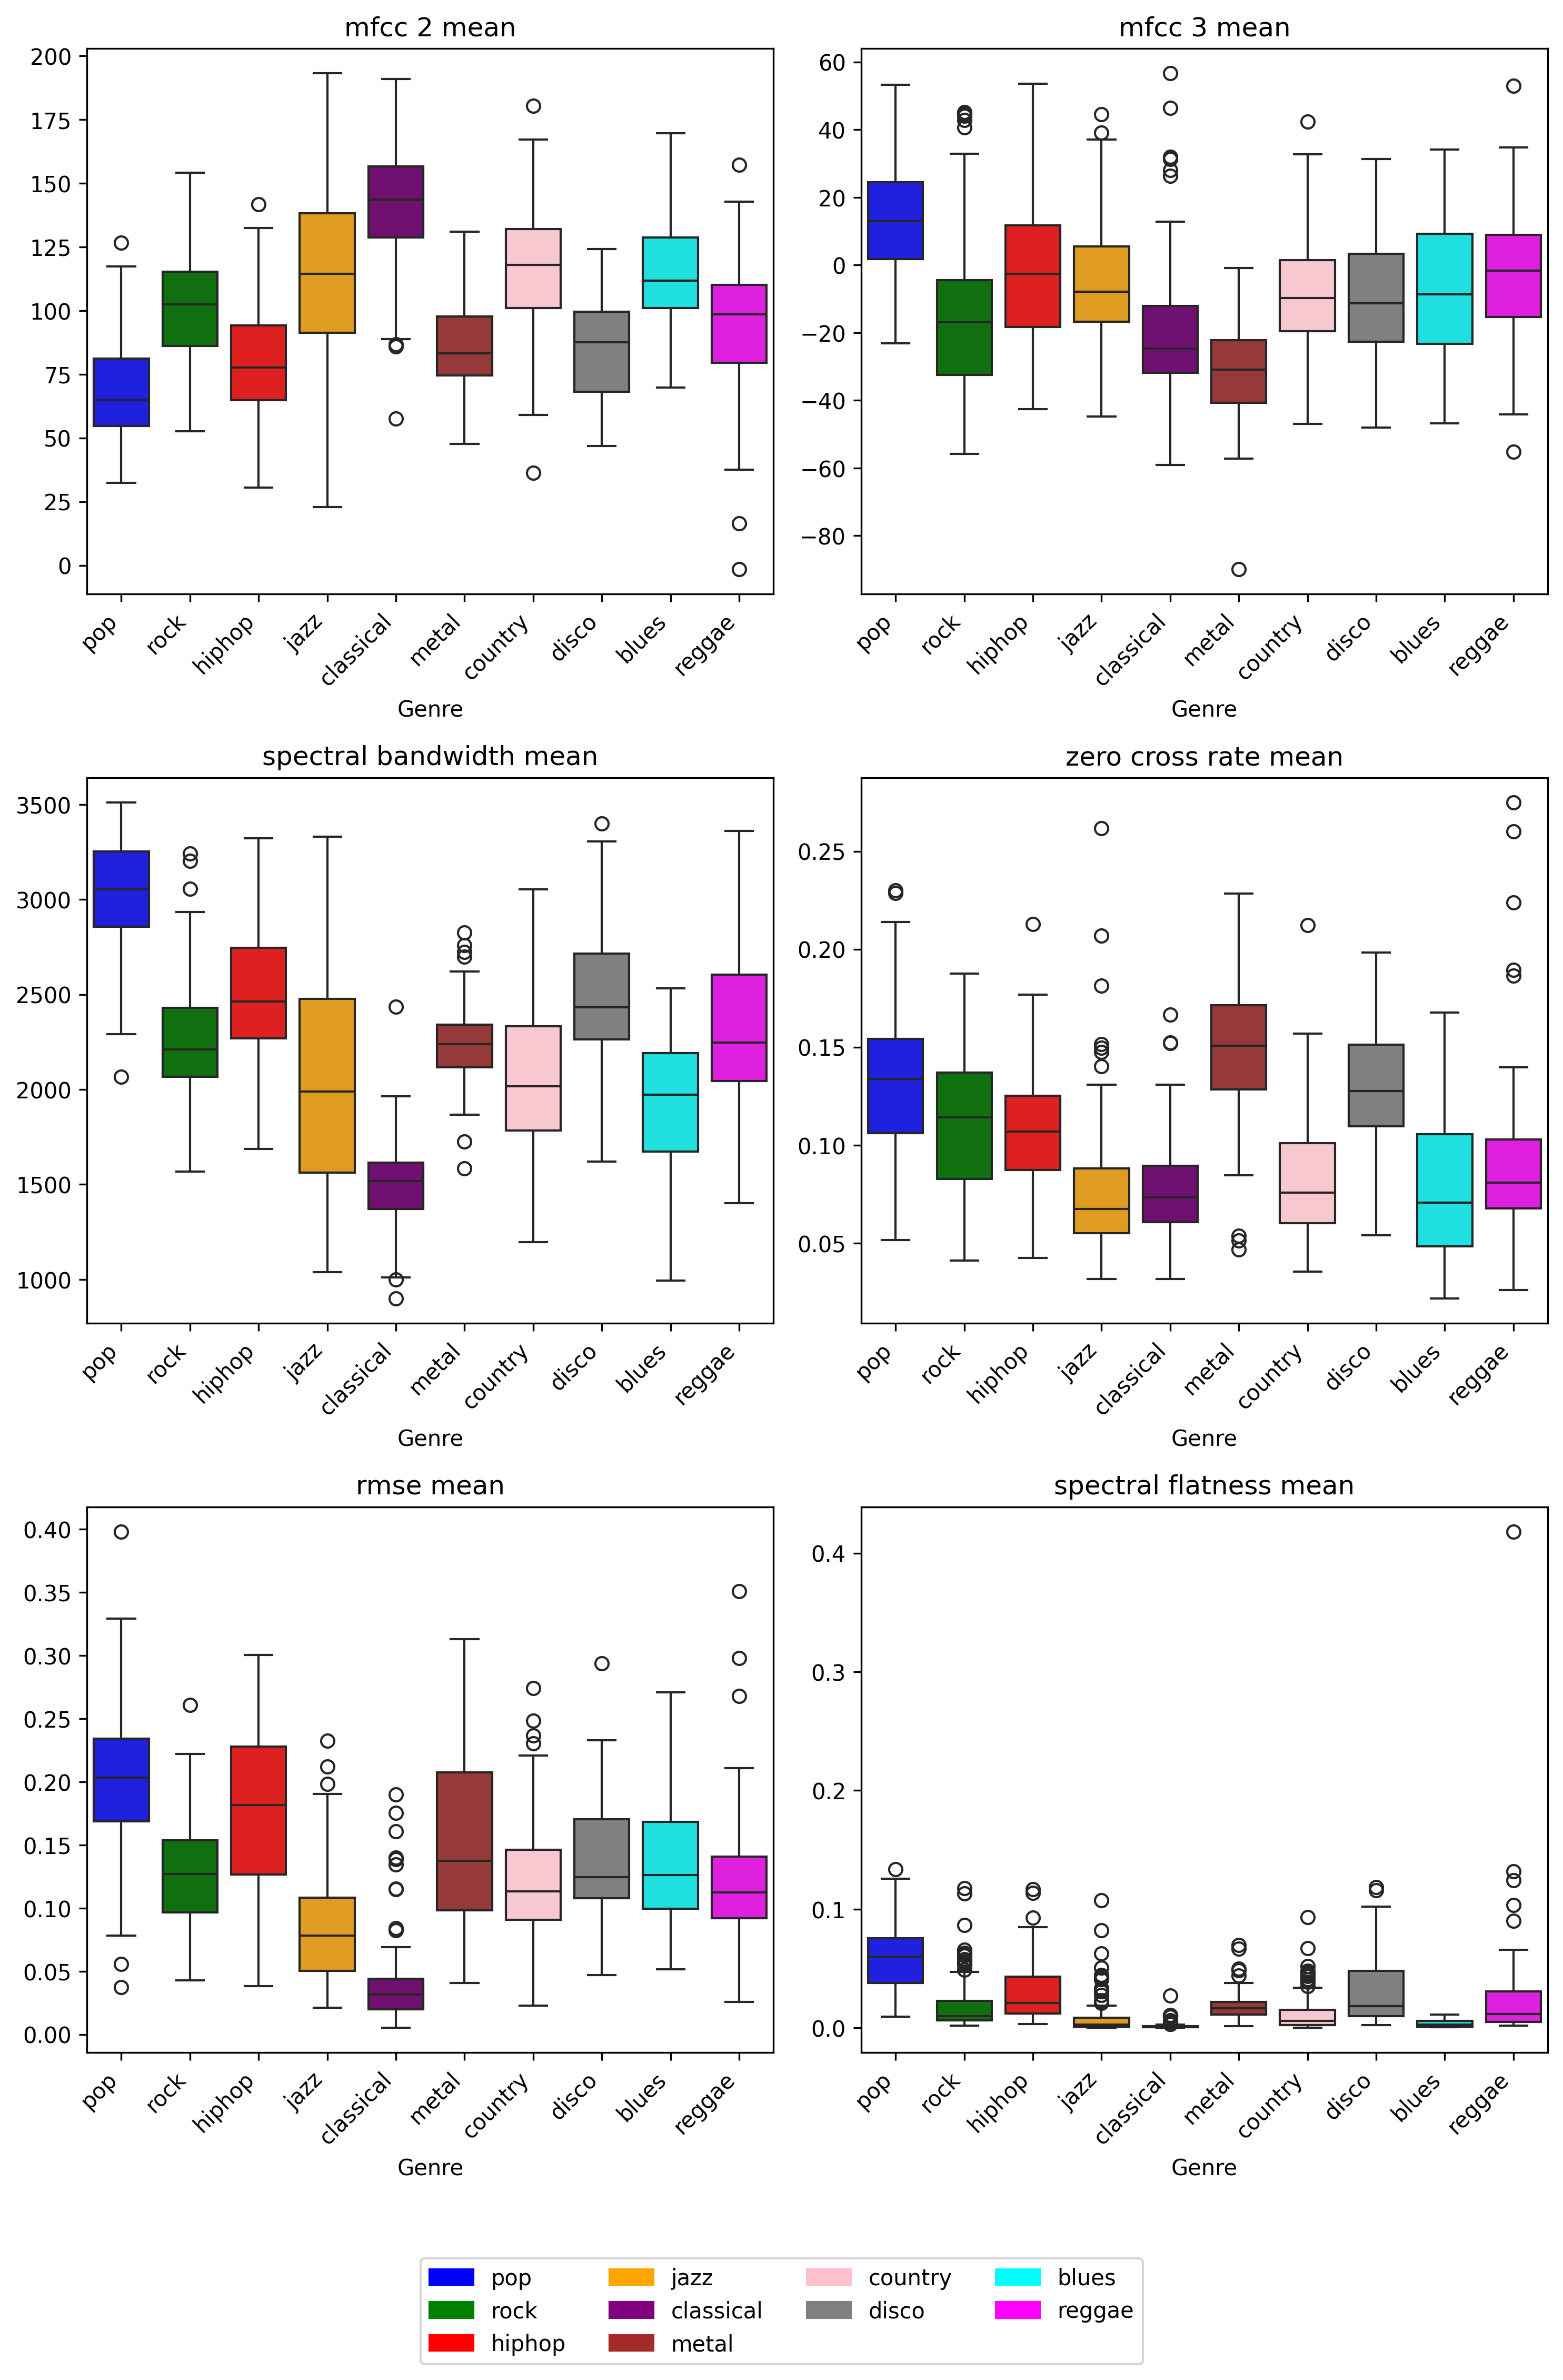

In [69]:
classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']


fig, axes = plt.subplots(3, 2, figsize=(10, 14), dpi=300)

sns.boxplot(data=Data_mfcc_2_mean, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title('mfcc 2 mean')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_xticks(range(len(classes)))
axes[0, 0].set_xticklabels(classes, rotation=45, ha='right')

sns.boxplot(data=Data_mfcc_3_mean, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title('mfcc 3 mean')
axes[0, 1].set_xlabel('Genre')
axes[0, 1].set_xticks(range(len(classes)))
axes[0, 1].set_xticklabels(classes, rotation=45, ha='right')

sns.boxplot(data=Data_spectral_bandwidth_mean, palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('spectral bandwidth mean')
axes[1, 0].set_xlabel('Genre')
axes[1, 0].set_xticks(range(len(classes)))
axes[1, 0].set_xticklabels(classes, rotation=45, ha='right')

sns.boxplot(data=Data_zero_cross_rate_mean, palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('zero cross rate mean')
axes[1, 1].set_xlabel('Genre')
axes[1, 1].set_xticks(range(len(classes)))
axes[1, 1].set_xticklabels(classes, rotation=45, ha='right')

sns.boxplot(data=Data_rmse_mean, palette=colors, ax=axes[2, 0])
axes[2, 0].set_title('rmse mean')
axes[2, 0].set_xlabel('Genre')
axes[2, 0].set_xticks(range(len(classes)))
axes[2, 0].set_xticklabels(classes, rotation=45, ha='right')

sns.boxplot(data=Data_spectral_flatness_mean, palette=colors, ax=axes[2, 1])
axes[2, 1].set_title('spectral flatness mean')
axes[2, 1].set_xlabel('Genre')
axes[2, 1].set_xticks(range(len(classes)))
axes[2, 1].set_xticklabels(classes, rotation=45, ha='right')

# Lag legend manuelt
handles = [
    mpatches.Patch(color=colors[i], label=classes[i])
    for i in range(len(classes))
]

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4)
plt.tight_layout()

#plt.savefig('Figures/boxplot_oppgave_3.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil

plt.show()


## Four chosen features

In [70]:
def load_genre_data_by_type_new(GenreClassData):
    cols_to_load = [2-1, 7-1, 11-1, 9-1, 42-1, 68-1]  
    col_names = ["name", 'spectral centroid mean', 'spectral rolloff mean', 'spectral bandwith mean', 'mfcc 1 mean', "type"] 
    
    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {7-1: float, 11-1: float, 9-1: float, 42-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    # Sett kolonnenavn
    data.columns = col_names 
    
    # Filtrer trenings- og testdata
    train_data = data[data['type'] == 'Train']
    test_data = data[data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    
    return train_data, test_data





### NOT Changing tempo

In [89]:
def load_genre_data_by_type_ex_feature(GenreClassData):
    #cols_to_load = [2-1, 7-1, 11-1, 41-1, 9-1, 68-1]  
    #col_names = ["name", 'spectral centroid mean', 'spectral rolloff mean', 'tempo',  'spectral bandwith mean', "type"] 
    
    #cols_to_load = [2-1, 7-1, 9-1, 41-1, 42-1,  68-1]  
    #col_names = ["name", 'spectral centroid mean', 'spectral bandwith mean','tempo', 'mfcc 1 mean', "type"] 
    
    cols_to_load = [2-1, 9-1, 11-1, 41-1, 42-1,  68-1]  
    col_names = ["name", 'spectral bandwith mean', 'spectral rolloff mean', 'tempo', 'mfcc 1 mean', "type"] 
    
    
    
    
    
    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {7-1: float, 11-1: float, 9-1: float, 42-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    # Sett kolonnenavn
    data.columns = col_names 
    
    # Filtrer trenings- og testdata
    train_data = data[data['type'] == 'Train']
    test_data = data[data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    
    return train_data, test_data

  
    

## EVALUATION

Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen
Klasser: ['pop', 'rock', 'hiphop', 'jazz', 'classical', 'metal', 'country', 'disco', 'blues', 'reggae']



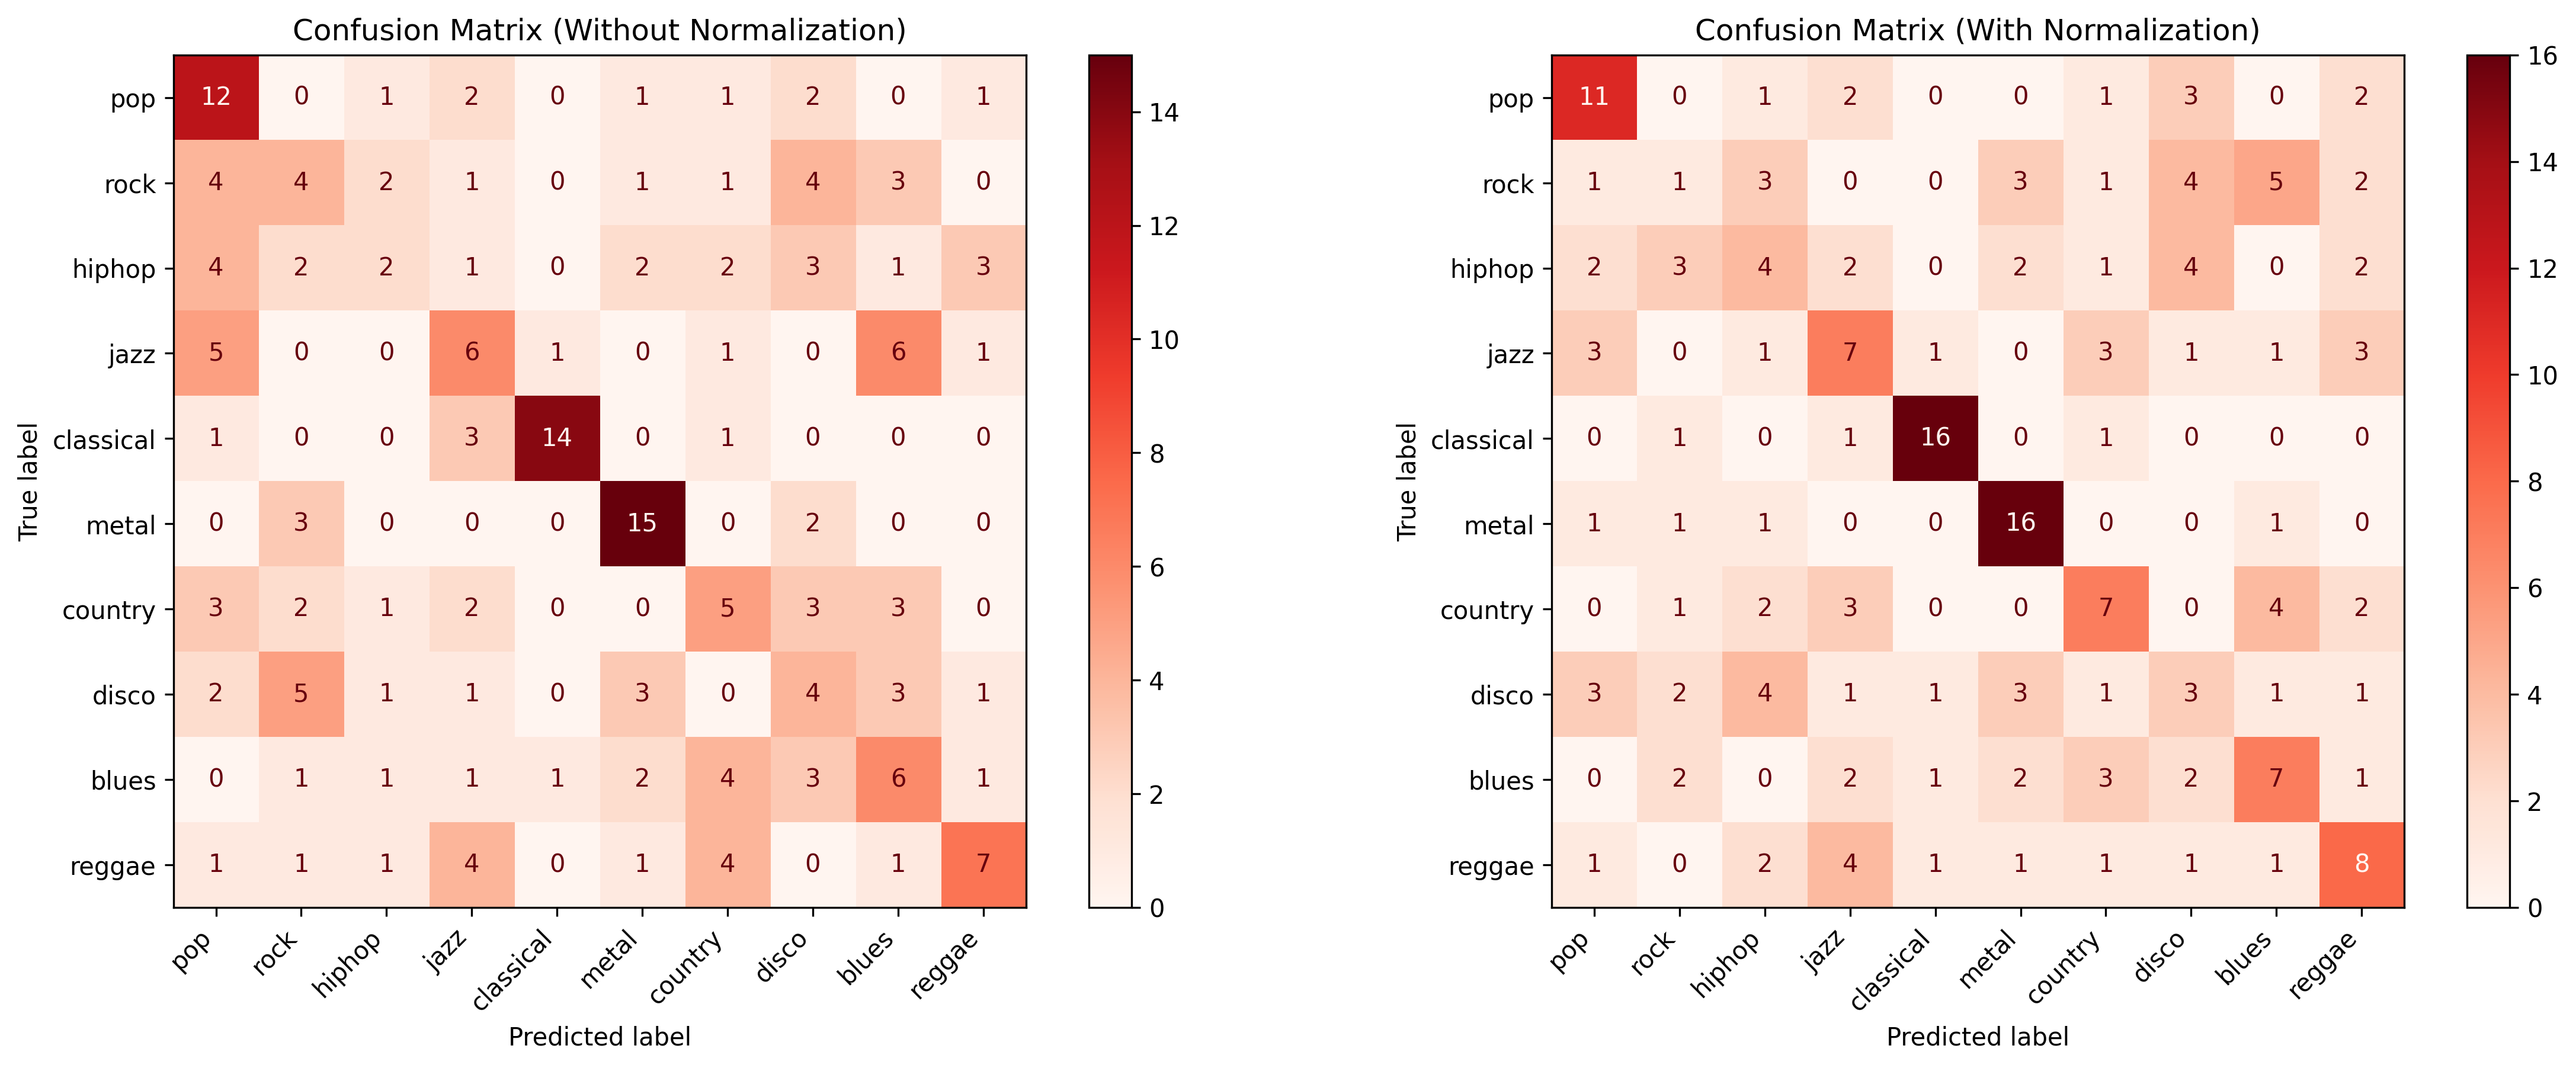


Accuracy: 37.88%
Accuracy med normalisert data: 40.40%


In [72]:

train_data, test_data = load_genre_data_by_type_new(GenreClassData)
classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]

# Eksempelbruk
k = 5
conf_matrix = evaluering(train_data, test_data, k) 
print(f"Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen")
print(f"Klasser: {classes}\n")

# Med normalisert data
train_scaled_with_name, test_scaled_with_name = load_scaled_data_with_names(train_data, test_data)
conf_matrix_normalized = evaluering(train_scaled_with_name, test_scaled_with_name, k)

# Plot begge confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Plot 1: Uten normalisering
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp1.plot(ax=ax[0], colorbar=True, cmap='Reds')
ax[0].set_title('Confusion Matrix (Without Normalization)')
ax[0].set_xticklabels(classes, rotation=45, ha='right')

# Plot 2: Med normalisering
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_normalized, display_labels=classes)
disp2.plot(ax=ax[1], colorbar=True, cmap='Reds')
ax[1].set_title('Confusion Matrix (With Normalization)')
ax[1].set_xticklabels(classes, rotation=45, ha='right')

plt.tight_layout()

#plt.savefig('Figures/cm_oppgave_3.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil

plt.show()

print(f"\nAccuracy: {accuracy_percent(conf_matrix):.2f}%")
print(f"Accuracy med normalisert data: {accuracy_percent(conf_matrix_normalized):.2f}%")

### NOT Changing tempo

Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen
Klasser: ['pop', 'rock', 'hiphop', 'jazz', 'classical', 'metal', 'country', 'disco', 'blues', 'reggae']



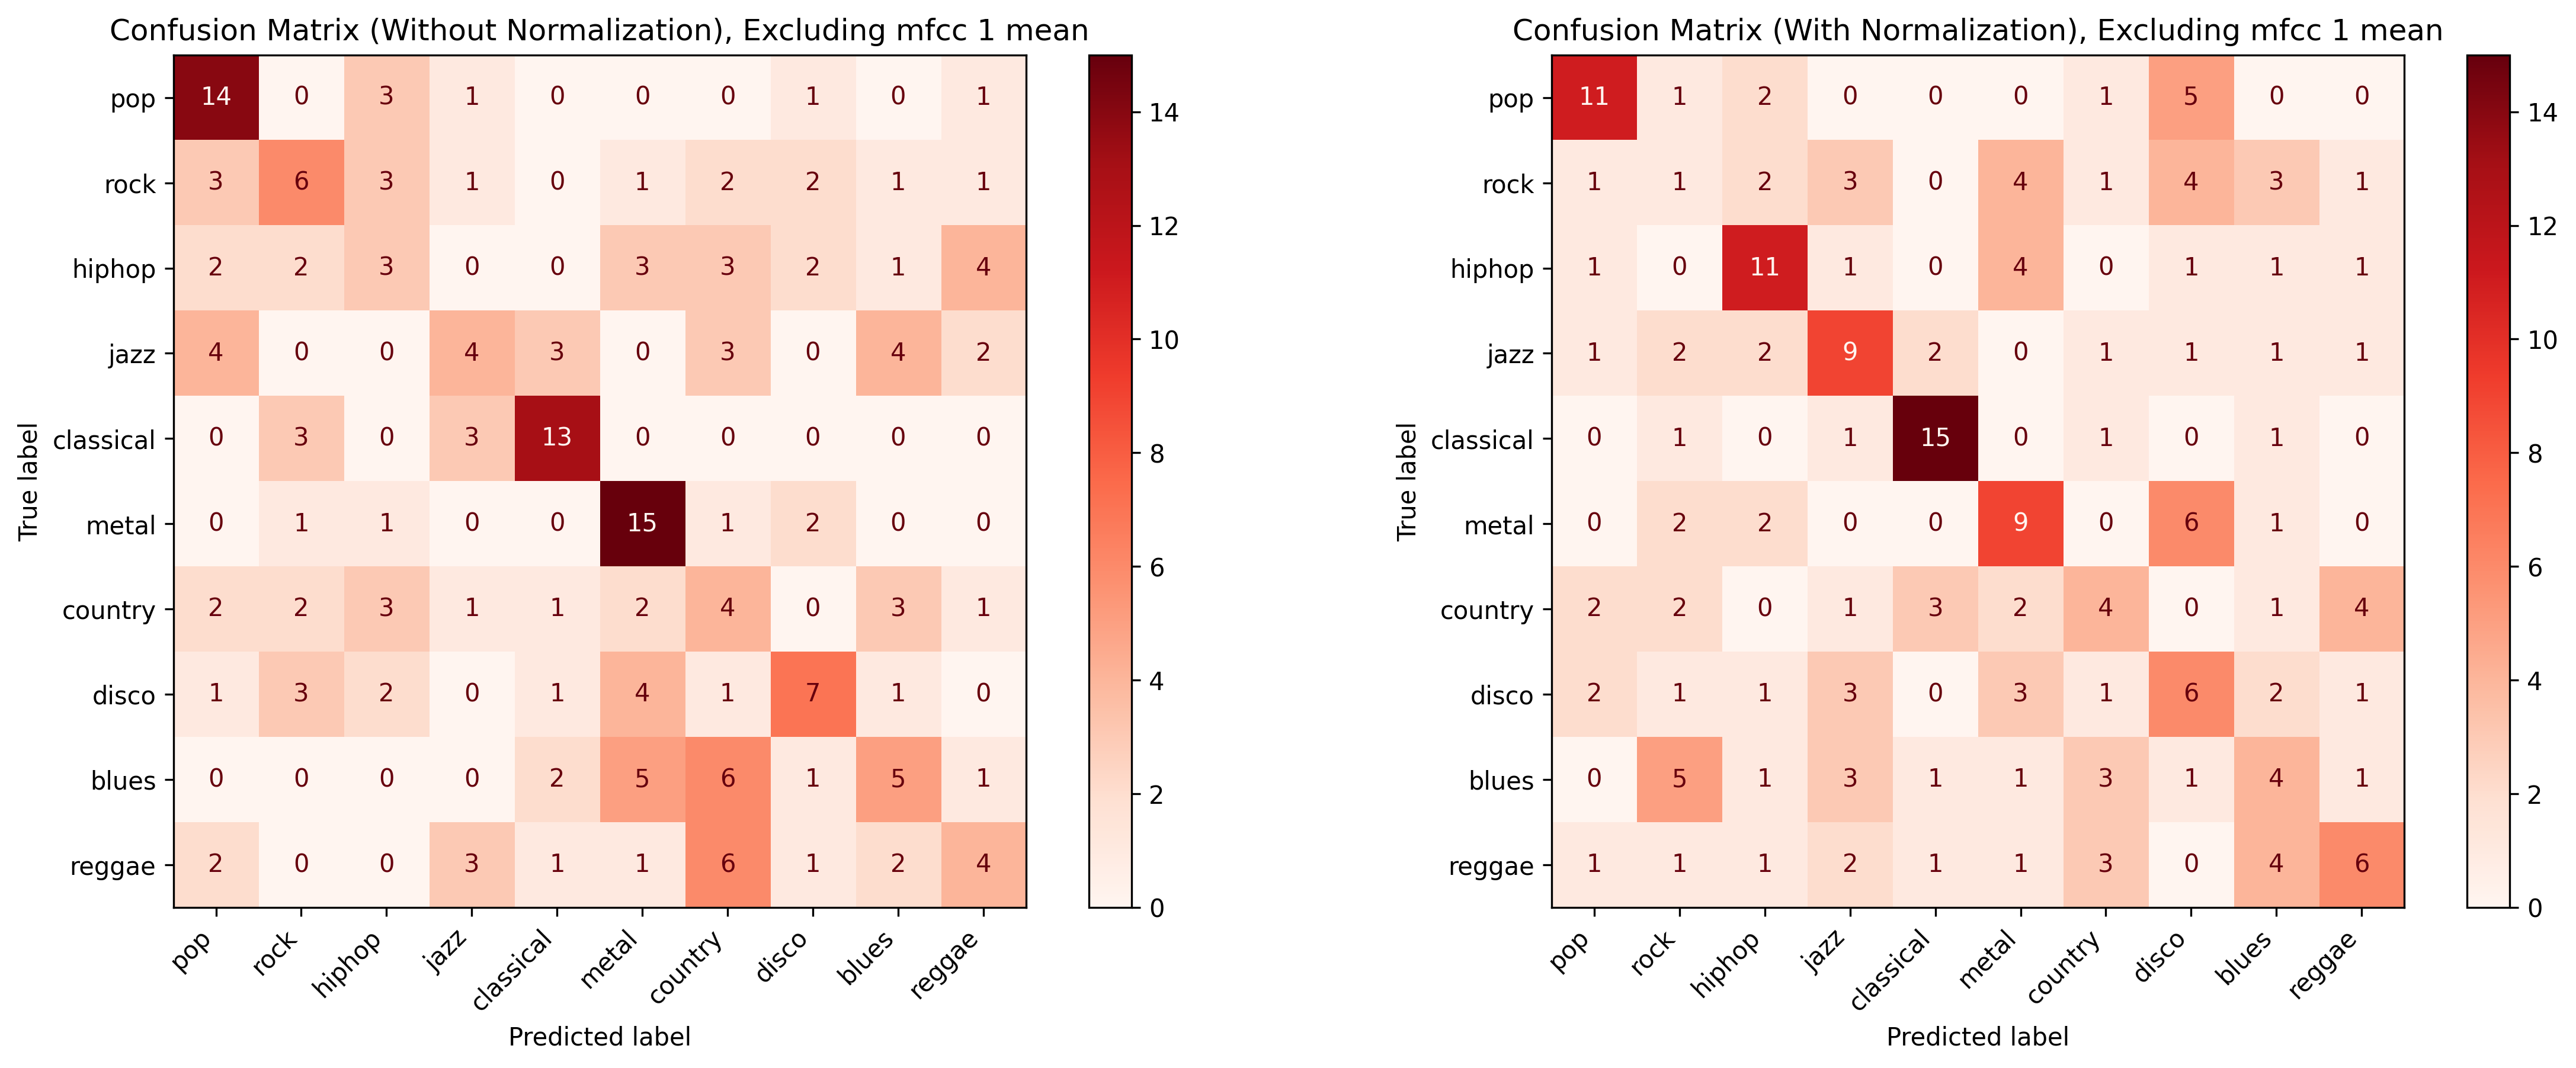


Accuracy: 37.88%
Accuracy med normalisert data: 38.38%


In [91]:

train_data, test_data = load_genre_data_by_type_ex_feature(GenreClassData)
classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]

# Eksempelbruk
k = 5
conf_matrix = evaluering(train_data, test_data, k) 
print(f"Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen")
print(f"Klasser: {classes}\n")

# Med normalisert data
train_scaled_with_name, test_scaled_with_name = load_scaled_data_with_names(train_data, test_data)
conf_matrix_normalized = evaluering(train_scaled_with_name, test_scaled_with_name, k)

# Plot begge confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Plot 1: Uten normalisering
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp1.plot(ax=ax[0], colorbar=True, cmap='Reds')
ax[0].set_title('Confusion Matrix (Without Normalization), Excluding mfcc 1 mean')
ax[0].set_xticklabels(classes, rotation=45, ha='right')

# Plot 2: Med normalisering
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_normalized, display_labels=classes)
disp2.plot(ax=ax[1], colorbar=True, cmap='Reds')
ax[1].set_title('Confusion Matrix (With Normalization), Excluding mfcc 1 mean')
ax[1].set_xticklabels(classes, rotation=45, ha='right')

plt.tight_layout()

#plt.savefig('Figures/cm_NOT_tempo_oppgave_3.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil

plt.show()

print(f"\nAccuracy: {accuracy_percent(conf_matrix):.2f}%")
print(f"Accuracy med normalisert data: {accuracy_percent(conf_matrix_normalized):.2f}%")

# OPPGAVE 4

In [74]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

## Velge data og funksjon

In [75]:
feature_indices = [
    42-1, 43-1, 44-1, 45-1, 46-1, 47-1, 48-1, 49-1, 50-1, 51-1,  # MFCC mean
    7-1, 9-1, 11-1, 15-1, 13-1,                        # spectral
    5-1, 3-1,                                    # energy
    41-1,                                      # tempo
    54-1, 8-1                                    # variance
]

feature_names = [
    # MFCC mean
    "name",
    "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean",
    "mfcc_5_mean", "mfcc_6_mean", "mfcc_7_mean", "mfcc_8_mean",
    "mfcc_9_mean", "mfcc_10_mean",

    # Spectral features
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
    "spectral_flatness_mean",
    "spectral_contrast_mean",

    # Energy / signal
    "rmse_mean",
    "zero_cross_rate_mean",

    # Rhythm
    "tempo",

    # Variance
    "mfcc_1_std",
    "spectral_centroid_var",

    "type"
]

def load_genre_data_by_type_final(GenreClassData):
    cols_to_load = [
    2-1,
    42-1, 43-1, 44-1, 45-1, 46-1, 47-1, 48-1, 49-1, 50-1, 51-1,  # MFCC mean
    7-1, 9-1, 11-1, 15-1, 13-1,                        # spectral
    5-1, 3-1,                                    # energy
    41-1,                                      # tempo
    54-1, 8-1,                                    # variance
    68-1
]
    feature_names = [
    # MFCC mean
    "name",
    "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean",
    "mfcc_5_mean", "mfcc_6_mean", "mfcc_7_mean", "mfcc_8_mean",
    "mfcc_9_mean", "mfcc_10_mean",

    # Spectral features
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
    "spectral_flatness_mean",
    "spectral_contrast_mean",

    # Energy / signal
    "rmse_mean",
    "zero_cross_rate_mean",

    # Rhythm
    "tempo",

    # Variance
    "mfcc_1_std",
    "spectral_centroid_var",

    "type"
]

    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {42-1: float, 43-1: float, 44-1: float, 45-1: float, 46-1: float, 47-1: float, 48-1: float, 49-1: float, 50-1: float, 51-1: float,
                    7-1: float, 9-1: float, 11-1: float, 15-1: float, 13-1: float,
                    5-1: float, 3-1: float,
                    41-1: float,
                    54-1: float, 8-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    # Sett kolonnenavn
    data.columns = feature_names 
    
    # Filtrer trenings- og testdata
    train_data = data[data['type'] == 'Train']
    test_data = data[data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    
    return train_data, test_data


## Laste inn data og normalisere

In [76]:
train_data, test_data = load_genre_data_by_type_final(GenreClassData)

scaler = StandardScaler()
train_data, test_data = load_scaled_data_with_names(train_data, test_data)

## Modeller og evaluering

### Model; RFC

In [77]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# Extract features (X) and labels (y)
features_train = train_data.iloc[:, 1:].values  # All columns except "Name"
labels_train = train_data.iloc[:, 0].str.split('_').str[0].values  # Genre from "Name" column

features_test = test_data.iloc[:, 1:].values
labels_test = test_data.iloc[:, 0].str.split('_').str[0].values

model.fit(features_train, labels_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Modell SVC

In [78]:
model2 = SVC(kernel='rbf', C=10, gamma='scale')
model2.fit(features_train, labels_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### EVALUERING

In [79]:
y_pred_RFC = model.predict(features_test)
print(f"Accuracy of RFC: {accuracy_score(labels_test, y_pred_RFC)*100:.2f}%")

y_pred_SVC = model2.predict(features_test)
print(f"Accuracy of SVC: {accuracy_score(labels_test, y_pred_SVC)*100:.2f}%")

Accuracy of RFC: 67.17%
Accuracy of SVC: 68.69%


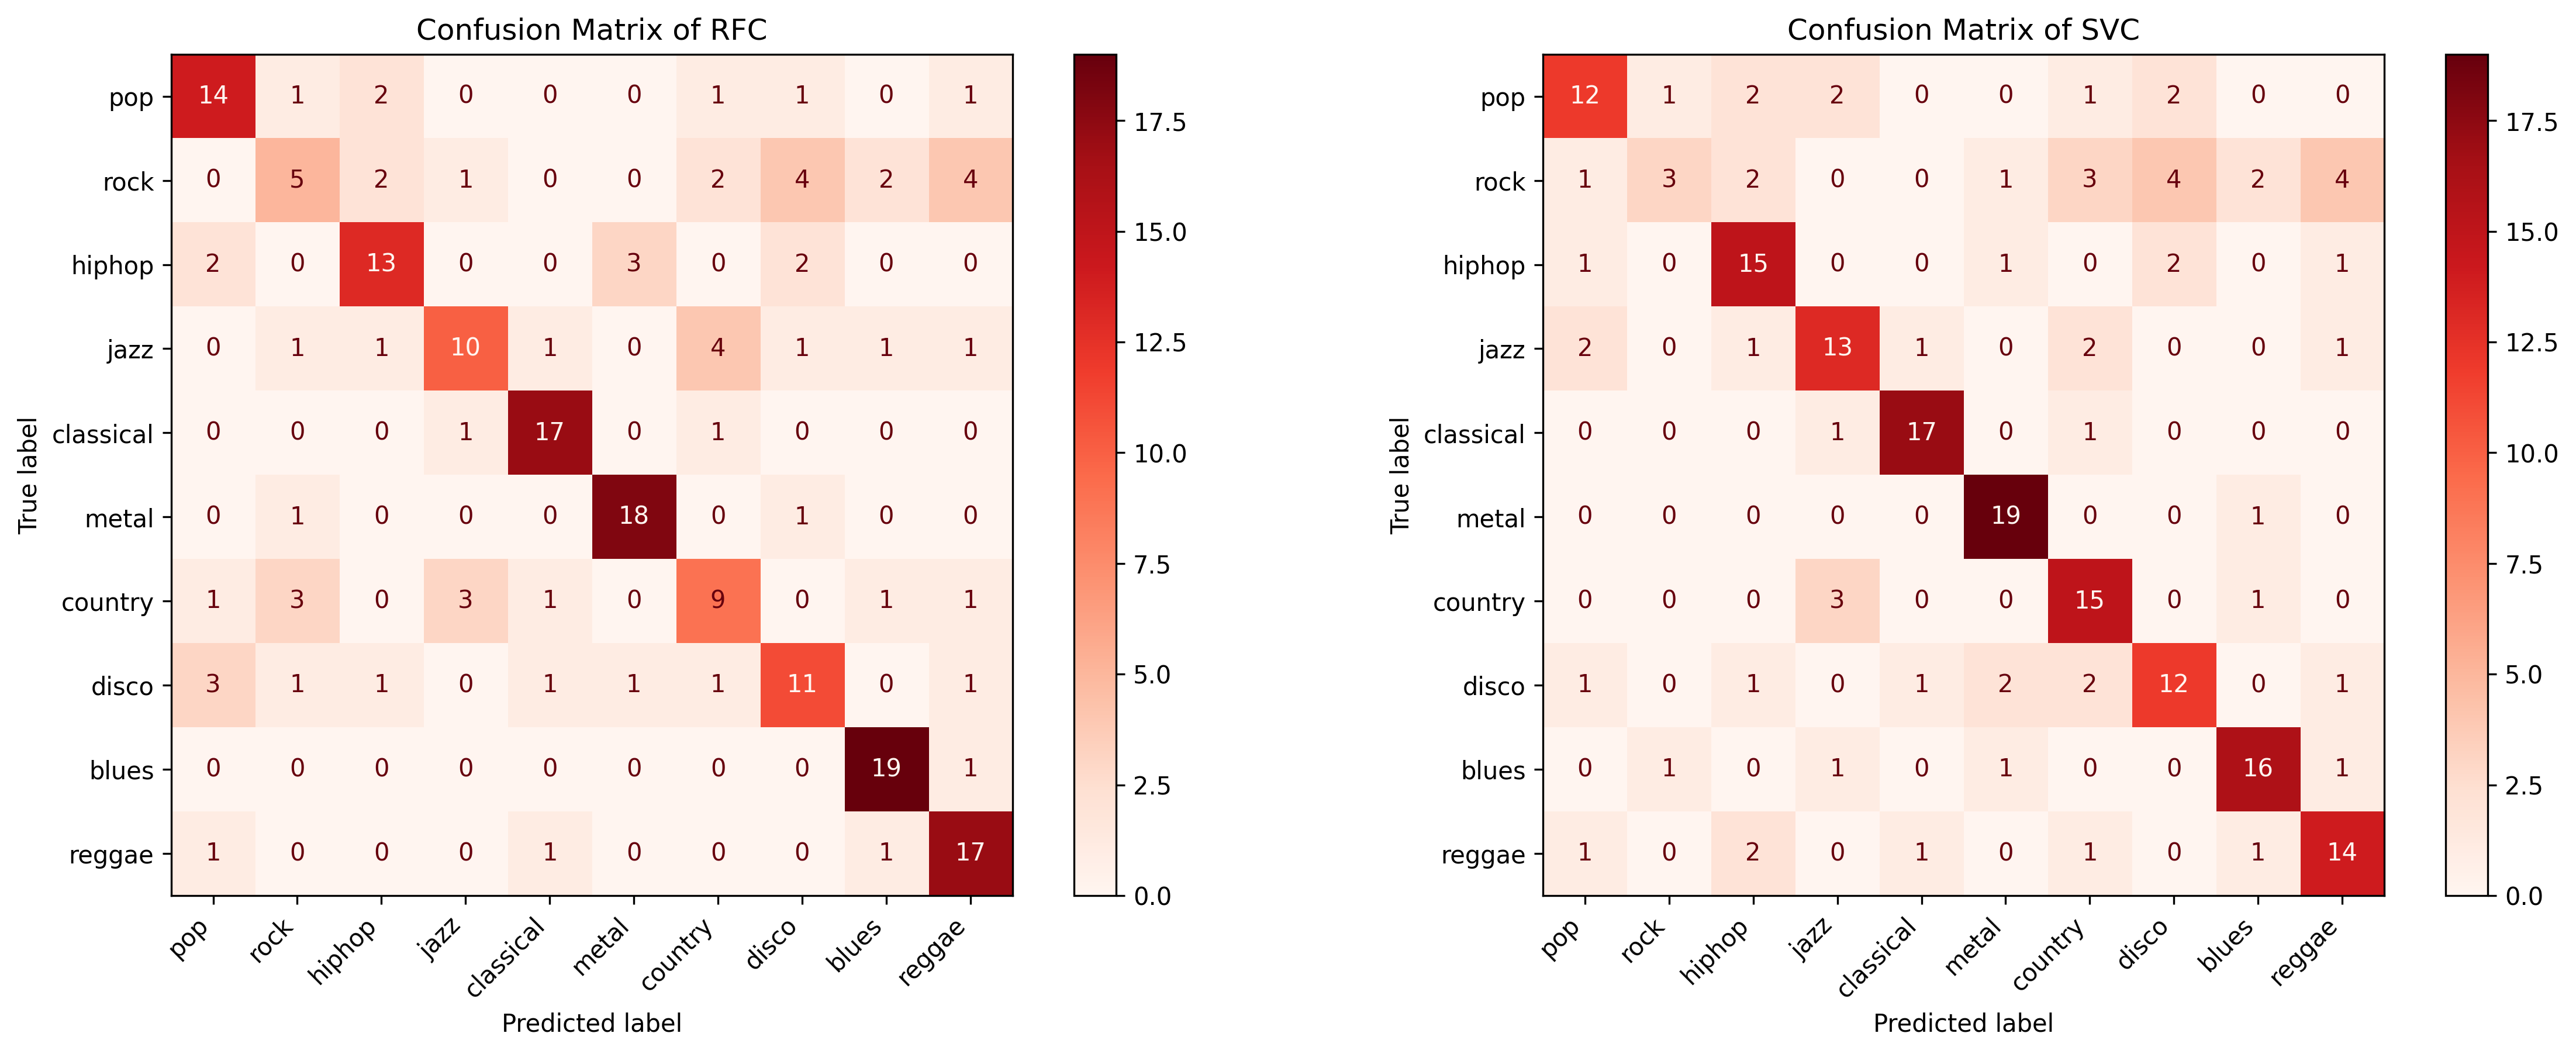

In [80]:
cm_RFC = confusion_matrix(labels_test, y_pred_RFC, labels=classes)
cm_SVC = confusion_matrix(labels_test, y_pred_SVC, labels=classes)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_RFC, display_labels=classes)
disp1.plot(ax=ax[0], colorbar=True, cmap='Reds')

ax[0].set_title('Confusion Matrix of RFC')
ax[0].set_xticklabels(classes, rotation=45, ha='right')


disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_SVC, display_labels=classes)
disp2.plot(ax=ax[1], colorbar=True, cmap='Reds')

ax[1].set_title('Confusion Matrix of SVC')
ax[1].set_xticklabels(classes, rotation=45, ha='right')

plt.tight_layout()



plt.savefig('Figures/cm_RFC_and_SVC_oppgave_4_30s.png', dpi=300, bbox_inches='tight')  # Lagre figuren som en PNG-fil
plt.show()